# Decision Tree Implementation and Comparison
**Assignment 5 - CART (Gini) vs ID3 (Entropy)**

**Name:** Shafikul Islam Marwan  
**Dataset:** Breast Cancer Wisconsin (Diagnostic)

---

This notebook implements and compares two Decision Tree algorithms:
- **CART** using the Gini impurity criterion
- **ID3** using the Entropy criterion

Both models are tuned using GridSearchCV and evaluated with full visualizations.

## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)

print('All libraries imported successfully.')

All libraries imported successfully.


## Step 2: Load Dataset from GitHub

In [2]:
url = ('https://raw.githubusercontent.com/Marwanthe0/CSE/main/'
       'Third%20Year/3-2/Artificial%20Intelligence%20and%20ML/'
       'Lab_04/Decision_Tree_Assignment/dataset/Breast_Cancer.csv')

df = pd.read_csv(url)
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## Step 3: Data Preprocessing

In [3]:
# Drop 'id' column (not a feature) and any fully empty columns
df.drop(columns=['id'], inplace=True)
df.dropna(axis=1, how='all', inplace=True)

print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

Missing values per column:
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

Total missing values: 0


In [4]:
# Fill any remaining missing numeric values with the column median
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Encode the target column: M -> 1, B -> 0
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])

print('Class distribution after encoding:')
print(df['diagnosis'].value_counts().rename(index={1: 'Malignant (1)', 0: 'Benign (0)'}))

Class distribution after encoding:
diagnosis
Benign (0)       357
Malignant (1)    212
Name: count, dtype: int64


In [5]:
# Separate features and target, then split into train/test
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples:  {X_test.shape[0]}')

Training samples: 455
Testing samples:  114


## Step 4: Hyperparameter Tuning with GridSearchCV

We search over `max_depth` and `min_samples_split` for both models using 5-fold stratified cross-validation.

In [6]:
param_grid = {
    'max_depth': [3, 4, 5, 6, 7, None],
    'min_samples_split': [2, 5, 10, 15]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- CART (Gini) ---
cart_base = DecisionTreeClassifier(criterion='gini', random_state=42)
cart_grid = GridSearchCV(cart_base, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
cart_grid.fit(X_train, y_train)

print('CART Best Parameters:', cart_grid.best_params_)
print(f'CART Best CV Accuracy: {cart_grid.best_score_:.4f}')

CART Best Parameters: {'max_depth': 7, 'min_samples_split': 15}
CART Best CV Accuracy: 0.9253


In [7]:
# --- ID3 (Entropy) ---
id3_base = DecisionTreeClassifier(criterion='entropy', random_state=42)
id3_grid = GridSearchCV(id3_base, param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
id3_grid.fit(X_train, y_train)

print('ID3 Best Parameters:', id3_grid.best_params_)
print(f'ID3 Best CV Accuracy: {id3_grid.best_score_:.4f}')

ID3 Best Parameters: {'max_depth': 4, 'min_samples_split': 2}
ID3 Best CV Accuracy: 0.9385


In [8]:
# Use the best estimators going forward
cart_model = cart_grid.best_estimator_
id3_model  = id3_grid.best_estimator_

# Predictions
cart_pred  = cart_model.predict(X_test)
id3_pred   = id3_model.predict(X_test)

cart_proba = cart_model.predict_proba(X_test)[:, 1]
id3_proba  = id3_model.predict_proba(X_test)[:, 1]

print('Models trained and predictions generated.')

Models trained and predictions generated.


## Step 5: Evaluation Metrics

In [9]:
def get_metrics(y_true, y_pred, y_proba):
    return {
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall'   : recall_score(y_true, y_pred),
        'F1-Score' : f1_score(y_true, y_pred),
        'AUC'      : roc_auc_score(y_true, y_proba)
    }

cart_metrics = get_metrics(y_test, cart_pred, cart_proba)
id3_metrics  = get_metrics(y_test, id3_pred,  id3_proba)

metrics_df = pd.DataFrame({'CART (Gini)': cart_metrics, 'ID3 (Entropy)': id3_metrics})
print(metrics_df.round(4))

           CART (Gini)  ID3 (Entropy)
Accuracy        0.9211         0.9298
Precision       0.9024         1.0000
Recall          0.8810         0.8095
F1-Score        0.8916         0.8947
AUC             0.9405         0.9431


## Step 6: Visualization 1 - Decision Boundary (PCA to 2D)

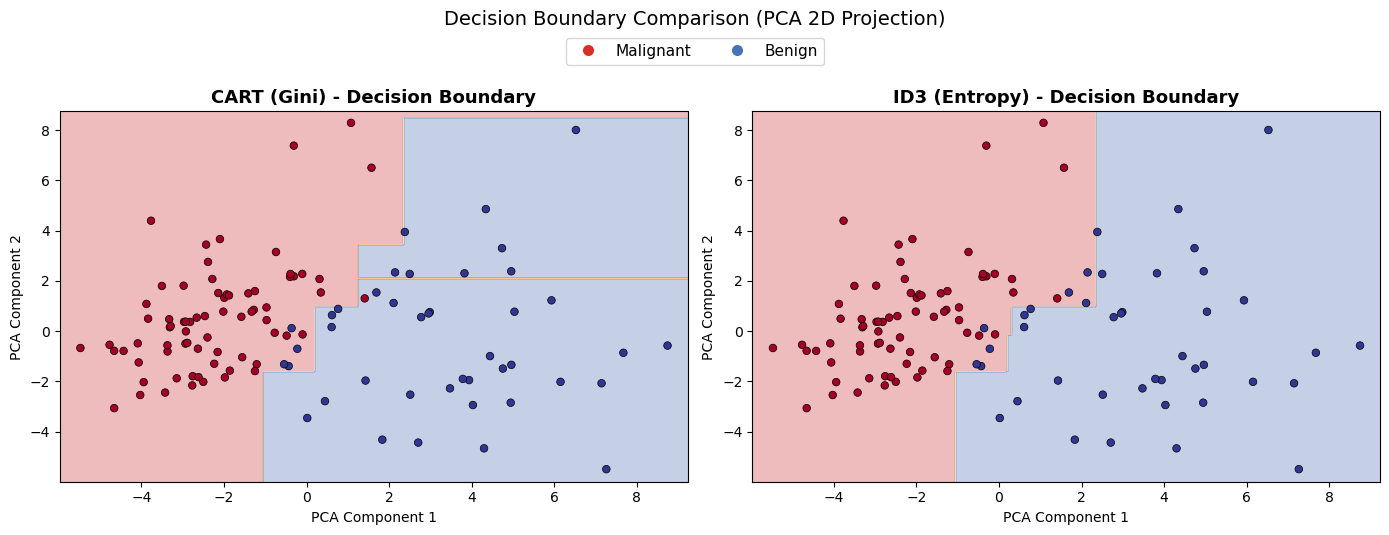

In [10]:
# Reduce to 2 components using PCA for plotting only
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

X_pca_train, X_pca_test, y_pca_train, y_pca_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

cart_pca = DecisionTreeClassifier(**cart_grid.best_params_, criterion='gini', random_state=42)
id3_pca  = DecisionTreeClassifier(**id3_grid.best_params_, criterion='entropy', random_state=42)
cart_pca.fit(X_pca_train, y_pca_train)
id3_pca.fit(X_pca_train, y_pca_train)

def plot_decision_boundary(ax, model, X_data, y_data, title):
    h = 0.05
    x_min, x_max = X_data[:, 0].min() - 0.5, X_data[:, 0].max() + 0.5
    y_min, y_max = X_data[:, 1].min() - 0.5, X_data[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    scatter = ax.scatter(X_data[:, 0], X_data[:, 1], c=y_data,
                         cmap='RdYlBu', edgecolors='k', s=30, linewidths=0.5)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('PCA Component 1')
    ax.set_ylabel('PCA Component 2')
    return scatter

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_decision_boundary(axes[0], cart_pca, X_pca_test, y_pca_test, 'CART (Gini) - Decision Boundary')
plot_decision_boundary(axes[1], id3_pca,  X_pca_test, y_pca_test, 'ID3 (Entropy) - Decision Boundary')

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#d73027', markersize=9, label='Malignant'),
           plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#4575b4', markersize=9, label='Benign')]
fig.legend(handles=handles, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.02), fontsize=11)
fig.suptitle('Decision Boundary Comparison (PCA 2D Projection)', fontsize=14, y=1.06)
plt.tight_layout()
plt.savefig('decision_boundary.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7: Visualization 2 - Confusion Matrix

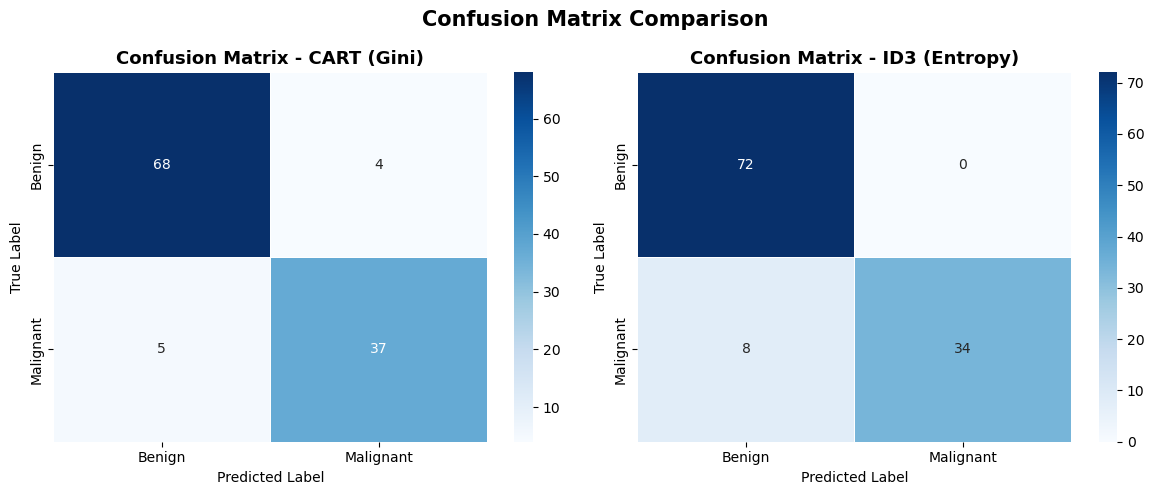

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
class_names = ['Benign', 'Malignant']

for ax, preds, title in zip(axes,
                             [cart_pred, id3_pred],
                             ['CART (Gini)', 'ID3 (Entropy)']):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, cbar=True)
    ax.set_title(f'Confusion Matrix - {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

fig.suptitle('Confusion Matrix Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8: Visualization 3 - ROC Curves

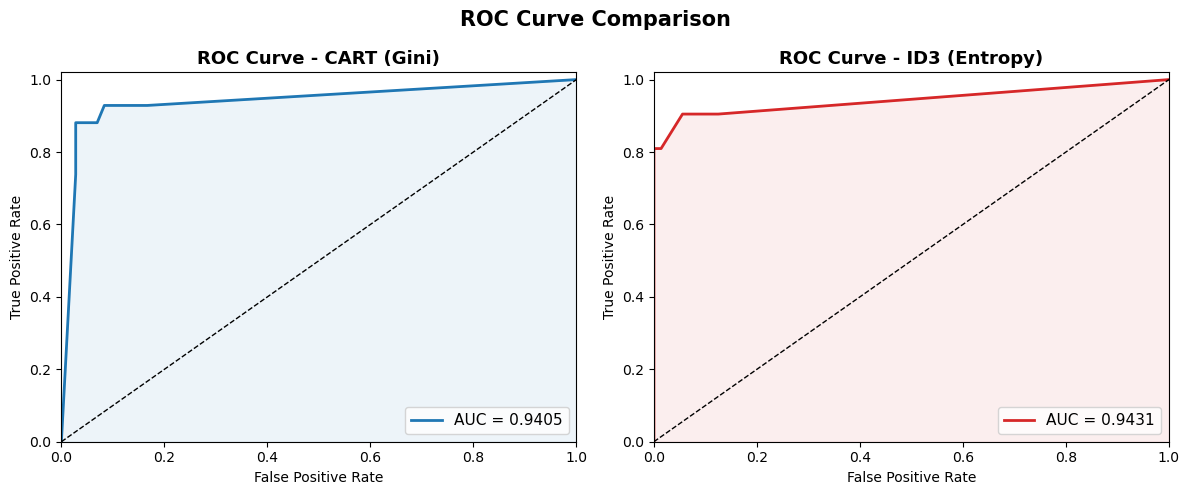

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, proba, title, color in zip(axes,
                                    [cart_proba, id3_proba],
                                    ['CART (Gini)', 'ID3 (Entropy)'],
                                    ['#1f77b4', '#d62728']):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'AUC = {auc_val:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.fill_between(fpr, tpr, alpha=0.08, color=color)
    ax.set_title(f'ROC Curve - {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=11)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

fig.suptitle('ROC Curve Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9: Visualization 4 - Evaluation Metrics Bar Chart

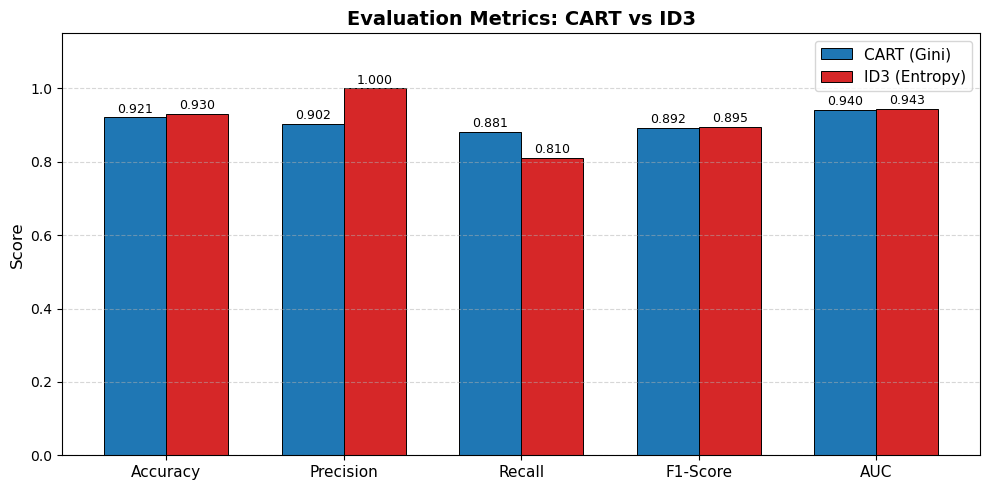

In [13]:
metric_names = list(cart_metrics.keys())
cart_vals    = list(cart_metrics.values())
id3_vals     = list(id3_metrics.values())

x   = np.arange(len(metric_names))
w   = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - w/2, cart_vals, w, label='CART (Gini)',    color='#1f77b4', edgecolor='black', linewidth=0.7)
bars2 = ax.bar(x + w/2, id3_vals,  w, label='ID3 (Entropy)', color='#d62728', edgecolor='black', linewidth=0.7)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Evaluation Metrics: CART vs ID3', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 10: Visualization 5 - Decision Tree Structure

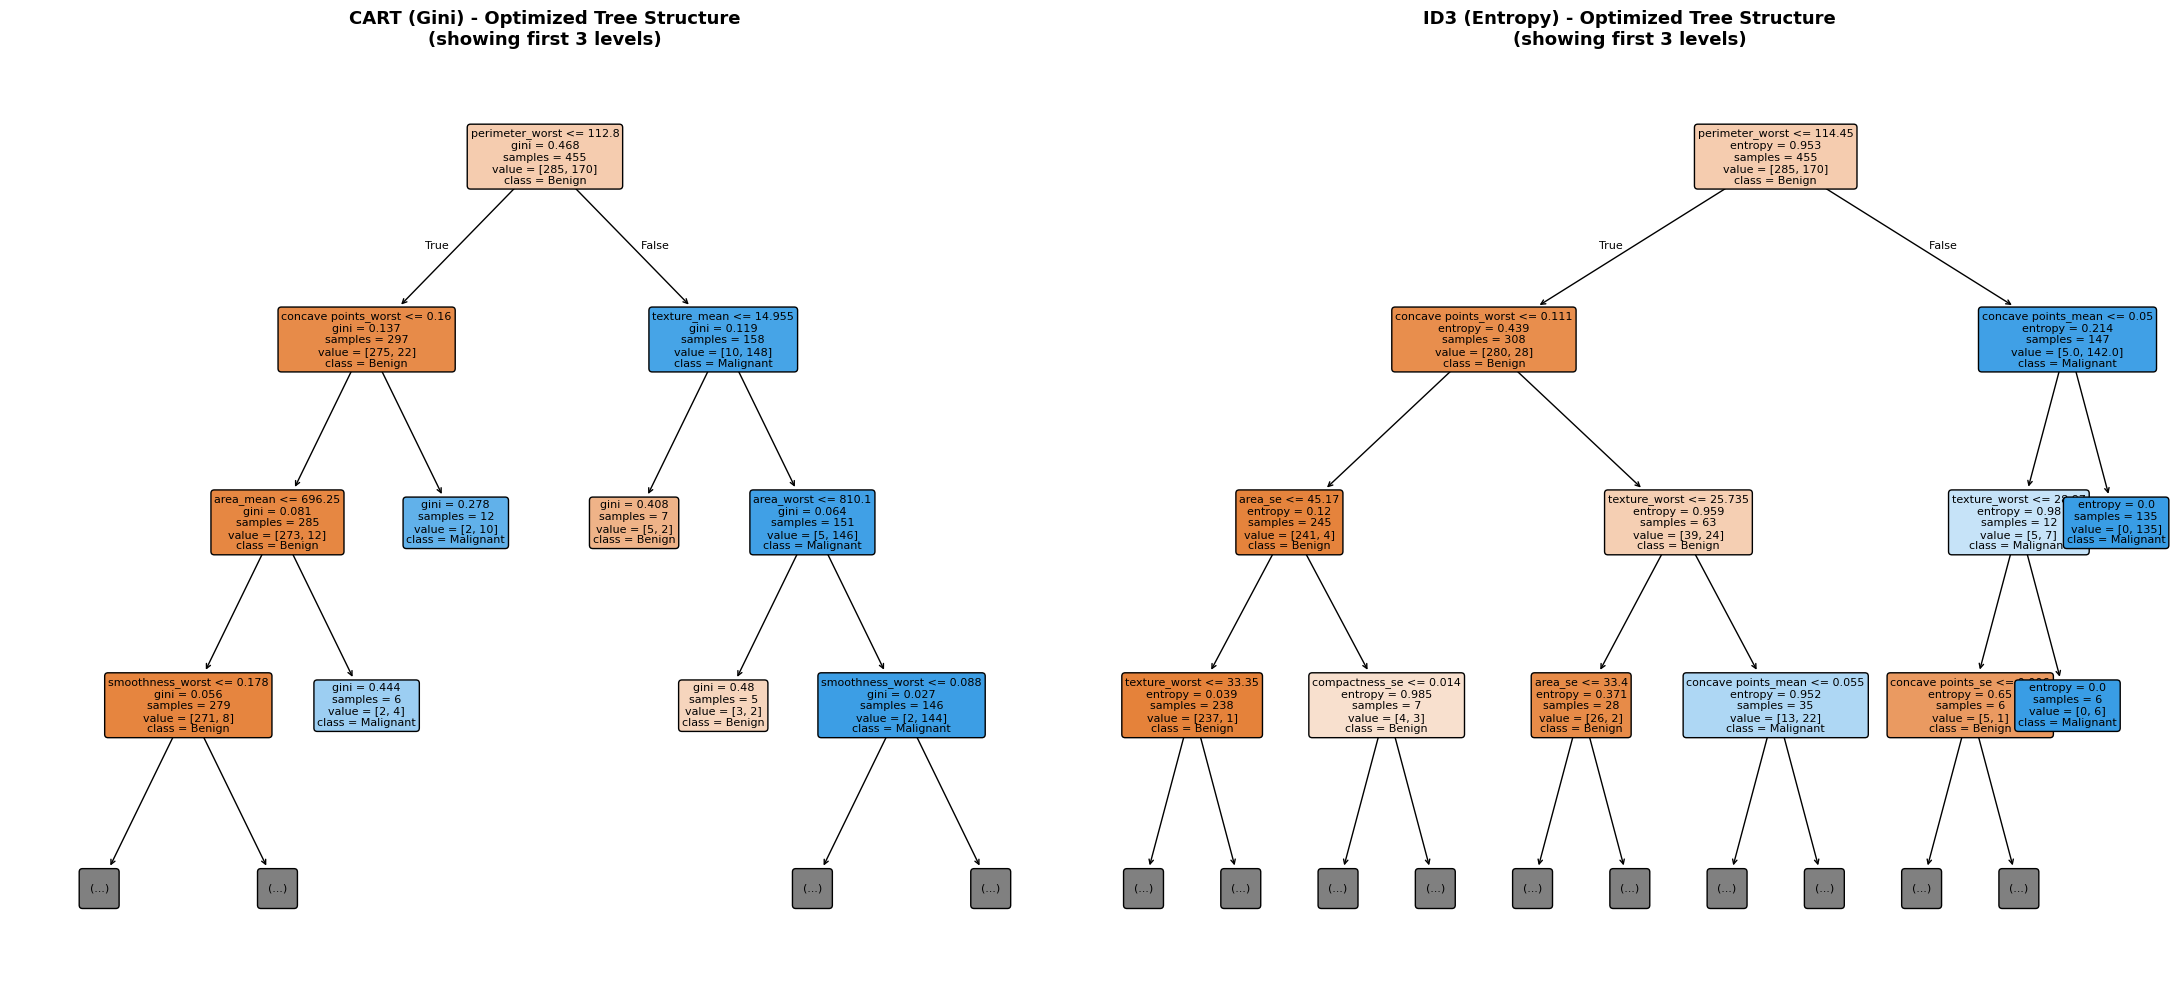

In [14]:
feature_names = list(X.columns)
class_names   = ['Benign', 'Malignant']

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

plot_tree(cart_model, ax=axes[0], max_depth=3, feature_names=feature_names,
          class_names=class_names, filled=True, rounded=True, fontsize=8,
          impurity=True, proportion=False)
axes[0].set_title('CART (Gini) - Optimized Tree Structure\n(showing first 3 levels)',
                  fontsize=13, fontweight='bold', pad=15)

plot_tree(id3_model, ax=axes[1], max_depth=3, feature_names=feature_names,
          class_names=class_names, filled=True, rounded=True, fontsize=8,
          impurity=True, proportion=False)
axes[1].set_title('ID3 (Entropy) - Optimized Tree Structure\n(showing first 3 levels)',
                  fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('tree_structure.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 11: Final Summary

In [15]:
print('=' * 55)
print('         FINAL MODEL COMPARISON SUMMARY')
print('=' * 55)
print(f'{"Metric":<15} {"CART (Gini)":>15} {"ID3 (Entropy)":>15}')
print('-' * 55)
for metric in metric_names:
    print(f'{metric:<15} {cart_metrics[metric]:>15.4f} {id3_metrics[metric]:>15.4f}')
print('=' * 55)
print(f'\nCART Best Params  : {cart_grid.best_params_}')
print(f'ID3  Best Params  : {id3_grid.best_params_}')

         FINAL MODEL COMPARISON SUMMARY
Metric              CART (Gini)   ID3 (Entropy)
-------------------------------------------------------
Accuracy                 0.9211          0.9298
Precision                0.9024          1.0000
Recall                   0.8810          0.8095
F1-Score                 0.8916          0.8947
AUC                      0.9405          0.9431

CART Best Params  : {'max_depth': 7, 'min_samples_split': 15}
ID3  Best Params  : {'max_depth': 4, 'min_samples_split': 2}


In [16]:
print('\nClassification Report - CART (Gini):')
print(classification_report(y_test, cart_pred, target_names=['Benign', 'Malignant']))

print('\nClassification Report - ID3 (Entropy):')
print(classification_report(y_test, id3_pred, target_names=['Benign', 'Malignant']))


Classification Report - CART (Gini):
              precision    recall  f1-score   support

      Benign       0.93      0.94      0.94        72
   Malignant       0.90      0.88      0.89        42

    accuracy                           0.92       114
   macro avg       0.92      0.91      0.91       114
weighted avg       0.92      0.92      0.92       114


Classification Report - ID3 (Entropy):
              precision    recall  f1-score   support

      Benign       0.90      1.00      0.95        72
   Malignant       1.00      0.81      0.89        42

    accuracy                           0.93       114
   macro avg       0.95      0.90      0.92       114
weighted avg       0.94      0.93      0.93       114



## Conclusion

Both the CART and ID3 models performed well on the Breast Cancer dataset. After tuning with GridSearchCV, the best hyperparameters were found for each model and the models were re-evaluated on the held-out test set.

**Key observations:**
- Both models achieved high accuracy, which is expected given the nature of this dataset.
- The Gini criterion (CART) and Entropy criterion (ID3) often arrive at similar trees but may differ slightly in how splits are chosen at each node.
- The ROC curves and AUC scores confirm that both models have strong discriminative ability between Benign and Malignant classes.
- PCA was used only for visualization purposes to project the 30-dimensional feature space into 2 dimensions. The actual models were trained on all original features.